### 1. Extracción
Dado que muchos sistemas de tickets (como Zendesk o Freshdesk) exportan archivos `.xls` que en realidad son `XML Spreadsheet 2003`, usar `pd.read_excel()` nos arrojaría un error. Este bloque usa `xml.etree.ElementTree` para parsear ese falso Excel y convertirlo en un DataFrame decente.

In [90]:
#pip install lxml pandas numpy matplotlib seaborn

In [91]:
from lxml import etree
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
import unicodedata

# Ruta del archivo
file_path = "./data/9000678639_tickets-April-24-2026-21_21.xls"

print("Iniciando extracción con parser tolerante a fallos")

# El parser con recover=True ignora los errores de sintaxis del XML
parser = etree.XMLParser(recover=True, huge_tree=True)
tree = etree.parse(file_path, parser=parser)
root = tree.getroot()

# El namespace de Microsoft
ns = {'ss': 'urn:schemas-microsoft-com:office:spreadsheet'}

data = []
for row in root.findall('.//ss:Row', namespaces=ns):
    row_data = []
    for cell in row.findall('.//ss:Cell', namespaces=ns):
        data_elem = cell.find('ss:Data', namespaces=ns)
        row_data.append(data_elem.text if data_elem is not None else None)

    # Solo agregamos la fila si tiene al menos un dato (evita filas fantasma)
    if any(row_data):
        data.append(row_data)

print("XML procesado. Construyendo DataFrame...")

# Creamos el DataFrame

if len(data) > 1:
    df_raw = pd.DataFrame(data[1:], columns=data[0])
    print(f"Dimensiones iniciales: {df_raw.shape}")
    display(df_raw.head(3))
else:
    print("Ocurrió un error, no se encontraron datos.")

Iniciando extracción con parser tolerante a fallos
XML procesado. Construyendo DataFrame...
Dimensiones iniciales: (10162, 45)


,ID del ticket,Asunto,Estado,Prioridad,Fuente,Tipo,Agente,Grupo,Tiempo de creación,Vencidas hasta ahora,...,Jefe de TI que aprueba la solicitud,Estado de la aprobación,Contacto,Teléfono,Ubicación del servicio,Hora de inicio de la cita,Hora de finalización de la cita,Firma del cliente,Nombre completo,ID de contacto
0,48543,URGENTE- MAS VENTAS MAS PREMIOS,Closed,Low,Portal,Solicitud Operativa,No Agent,No Group,2024-01-02 08:55:58,2024-01-03 18:00:00,...,None,None,None,None,None,None,None,None,Alexia Trujillo,atrujillom@promotick.com
1,48544,Fuera de oficina Re: ANULAR TRANSACCIÓN BENEFIT,Closed,Low,Email,None,No Agent,No Group,2024-01-02 09:27:55,2024-01-04 09:27:55,...,None,None,None,None,None,None,None,None,Francis Vargas,fvargas@promotick.com
2,48545,enviar pedido no procesado,Closed,Low,Portal,Solicitud Operativa,No Agent,No Group,2024-01-02 09:30:09,2024-01-04 09:30:09,...,None,None,None,None,None,None,None,None,jassmin Ramirez,jramirez@promotick.com


In [92]:
df_raw.describe()

,ID del ticket,Asunto,Estado,Prioridad,Fuente,Tipo,Agente,Grupo,Tiempo de creación,Vencidas hasta ahora,...,Jefe de TI que aprueba la solicitud,Estado de la aprobación,Contacto,Teléfono,Ubicación del servicio,Hora de inicio de la cita,Hora de finalización de la cita,Firma del cliente,Nombre completo,ID de contacto
count,10162,10161,10162,10162,10162,10094,10162,10162,10162,10162,...,4869,4869,0,0,0,0,0,0,10162,10162
unique,10162,7344,2,4,3,11,9,6,10156,9594,...,3,4,0,0,0,0,0,0,207,228
top,59324,Plantilla Enjoy,Closed,Low,Portal,Solicitud Operativa,No Agent,No Group,2024-05-11 16:23:42,2024-11-20 18:00:00,...,No requiere aprobación,No aplica,NaN,NaN,NaN,NaN,NaN,NaN,Doménica Aguirre,comercial2@motivasoluciones.com
freq,1,211,10155,8177,9465,4397,8309,5286,3,48,...,3320,3320,NaN,NaN,NaN,NaN,NaN,NaN,416,416


In [93]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10162 entries, 0 to 10161
Data columns (total 45 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   ID del ticket                          10162 non-null  object
 1   Asunto                                 10161 non-null  object
 2   Estado                                 10162 non-null  object
 3   Prioridad                              10162 non-null  object
 4   Fuente                                 10162 non-null  object
 5   Tipo                                   10094 non-null  object
 6   Agente                                 10162 non-null  object
 7   Grupo                                  10162 non-null  object
 8   Tiempo de creación                     10162 non-null  object
 9   Vencidas hasta ahora                   10162 non-null  object
 10  Tiempo de resolución                   10162 non-null  object
 11  Hora de cierre 

### Fase 1: Limpieza General y Normalización (Nivel I)

Este bloque de código ejecuta la etapa inicial de preparación y homogeneización del DataFrame, asegurando la consistencia en los metadatos y la estructura de los datos antes de proceder con el análisis.

**Operaciones realizadas:**

* **Preservación de datos:** Crea una copia de seguridad (`df_nivel1`) a partir de `df_raw` para mantener intactos los datos de origen.
* **Normalización de columnas:** Transforma los nombres de las variables al estándar `snake_case` (minúsculas, eliminación de acentos, diéresis y sustitución de caracteres especiales o espacios por guiones bajos).
* **Depuración de cadenas:** Elimina los espacios en blanco iniciales y finales en los campos de tipo texto (`.strip()`).
* **Estandarización de valores nulos:** Reemplaza marcadores de posición textuales (como `"None"`, `"NaN"` o celdas vacías) por valores nulos oficiales de NumPy (`np.nan`).
* **Reducción de dimensionalidad:** Detecta y elimina aquellas columnas que carecen por completo de información (`how='all'`).
* **Validación:** Imprime un resumen de control con las dimensiones resultantes y la estructura técnica actual del DataFrame.

In [94]:
# Hacemos una copia para no arruinar el df_raw por si acaso
df_nivel1 = df_raw.copy()

# Función para transformar los nombres a snake_case y sin tildes
def clean_column_name(name):
    # Quitar acentos y diéresis
    name = ''.join(c for c in unicodedata.normalize('NFD', name) if unicodedata.category(c) != 'Mn')
    # Minúsculas y reemplazar espacios o caracteres extraños por guiones bajos
    name = name.lower().strip()
    name = re.sub(r'[\s\-/\\\(\)\.,\?]+', '_', name)
    name = re.sub(r'_+', '_', name) # Evitar dobles guiones bajos un__nombre
    return name.strip('_')

df_nivel1.columns = [clean_column_name(col) for col in df_nivel1.columns]

# Limpieza de espacios en blanco invisibles dentro de los strings
df_nivel1 = df_nivel1.apply(lambda s: s.str.strip() if s.dtype == "object" else s)

# Reemplazar los strings que simulan estar vacíos o dicen "None"/"NaN" por NaNs reales de Numpy
placeholders_nulos = ["None", "NaN", "nan", "", "null", "Null"]
df_nivel1.replace(placeholders_nulos, np.nan, inplace=True)

# Eliminar columnas que están completamente vacías
cols_antes = df_nivel1.shape[1]
df_nivel1.dropna(how='all', axis=1, inplace=True)
cols_despues = df_nivel1.shape[1]

print(f"Fase 1 completada.")
print(f"Columnas eliminadas (100% nulas): {cols_antes - cols_despues}")
print(f"Nuevas dimensiones del DataFrame: {df_nivel1.shape}")
# Validar el impacto del Nivel I
print("\n--- Inspección Post-Nivel I ---")
df_nivel1.info()

Fase 1 completada.
Columnas eliminadas (100% nulas): 8
Nuevas dimensiones del DataFrame: (10162, 37)

--- Inspección Post-Nivel I ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10162 entries, 0 to 10161
Data columns (total 37 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   id_del_ticket                        10162 non-null  object
 1   asunto                               10161 non-null  object
 2   estado                               10162 non-null  object
 3   prioridad                            10162 non-null  object
 4   fuente                               10162 non-null  object
 5   tipo                                 10094 non-null  object
 6   agente                               10162 non-null  object
 7   grupo                                10162 non-null  object
 8   tiempo_de_creacion                   10162 non-null  object
 9   vencidas_hasta_ahora                 

### Eliminar variables descontinuadas

Eliminar variables que no aportan valor analítico o que han sido descontinuadas según lo indicado por el representante de Promotick. Esto permite reducir ruido en los datos y mantener únicamente información relevante para el análisis.

Se eliminan las siguientes variables:

- "tiempo_de_seguimiento": no utilizada en los procesos actuales.
- "estado_de_la_aprobación": campo asociado a aprobaciones no relevante  para el análisis.
- "jefe_de_ti_que_aprueba_la_solicitud": variable administrativa sin valor analítico.
- "producto": columna sin información (vacía).
- "id_de_contacto": identificador no necesario para el análisis de negocio.

In [95]:
df_nivel1.drop(columns=[ "tiempo_de_seguimiento", "estado_de_la_aprobacion", "jefe_de_ti_que_aprueba_la_solicitud","producto","id_de_contacto"],
        inplace=True)

### Fase 2: Casteo de Tipos y Tratamiento de Duraciones (Nivel II)

Este bloque de código ejecuta la segunda etapa de preparación de los datos, enfocada en la conversión estricta de tipos de datos (*type casting*) y en la transformación de cadenas de texto complejas en métricas numéricas analizables.

**Operaciones realizadas:**

* **Preservación de datos:** Modifica una nueva copia de seguridad (`df_nivel2`) a partir del DataFrame normalizado en la fase anterior.
* **Conversión cronológica:** Transforma las columnas analógicas de marcas de tiempo (`cols_fechas`) al formato nativo `datetime64[ns]` de Pandas, forzando como nulos (`errors='coerce'`) los registros con errores de sintaxis.
* **Preservación de identificadores:** Convierte la variable `id_del_ticket` a tipo cadena de texto (`str`) para evitar cálculos aritméticos accidentales o pérdida de ceros a la izquierda.
* **Homogeneización de contadores:** Fuerza las variables de conteo de interacciones a tipo numérico y las almacena bajo el formato `Int64` (entero nativo de Pandas que admite valores nulos).
* **Procesamiento de duraciones textuales:** Identifica las columnas con formato de tiempo compuesto (`0 days HH:MM:SS`), las convierte temporalmente a `timedelta` y calcula el equivalente total en horas con precisión decimal (`float`).
* **Validación de métricas:** Asegura que los indicadores numéricos continuos (como `tiempo_empleado`) queden tipificados correctamente como punto flotante (`float64`).
* **Auditoría:** Muestra una previsualización de los cálculos de tiempo y despliega la nueva estructura técnica consolidada del dataset.

In [96]:
df_nivel2 = df_nivel1.copy()

print("Ejecutando Nivel II: Tratamiento de duraciones encubiertas")

# Fechas puras (Datetime)
cols_fechas = [
    'tiempo_de_creacion',
    'vencidas_hasta_ahora',
    'hora_de_cierre',
    'ultima_hora_de_la_actualizacion',
    'inicio_de_atencion',
    'fin_de_atencion'
]
for col in cols_fechas:
    df_nivel2[col] = pd.to_datetime(df_nivel2[col], errors='coerce')

# Identificadores categóricos / Texto seguro
df_nivel2['id_del_ticket'] = df_nivel2['id_del_ticket'].astype(str)


# Conteos de interacciones (Enteros con soporte de NaNs)
cols_enteros = ['interacciones_de_agente', 'interacciones_de_cliente']
for col in cols_enteros:
    df_nivel2[col] = pd.to_numeric(df_nivel2[col], errors='coerce').astype('Int64')

# Duraciones que dicen "en horas" pero vienen como '0 days HH:MM:SS'
cols_duracion_texto = ['primer_tiempo_de_respuesta_en_horas', 'tiempo_de_resolucion_en_horas']
for col in cols_duracion_texto:
    # Convertimos a timedelta y luego extraemos el total de horas reales en formato float
    timedelta_temp = pd.to_timedelta(df_nivel2[col], errors='coerce')
    df_nivel2[col] = timedelta_temp.dt.total_seconds() / 3600.0

# Métricas numéricas que ya son floats puros
df_nivel2['tiempo_empleado'] = pd.to_numeric(df_nivel2['tiempo_empleado'], errors='coerce')

print(f"Dimensiones del DataFrame: {df_nivel2.shape}")

# Verificar que las horas flotantes ahora sí tengan sentido y no sean nulos
print("\n--- Muestra de las horas calculadas (primeras 3 filas) ---")
print(df_nivel2[cols_duracion_texto].head(3))

Ejecutando Nivel II: Tratamiento de duraciones encubiertas
Dimensiones del DataFrame: (10162, 32)

--- Muestra de las horas calculadas (primeras 3 filas) ---
   primer_tiempo_de_respuesta_en_horas  tiempo_de_resolucion_en_horas
0                             0.256389                       0.260000
1                             0.000000                       0.033333
2                             0.617222                      20.044167


Estructura final del dataset para Nivel III

In [97]:
df_nivel2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10162 entries, 0 to 10161
Data columns (total 32 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   id_del_ticket                        10162 non-null  object        
 1   asunto                               10161 non-null  object        
 2   estado                               10162 non-null  object        
 3   prioridad                            10162 non-null  object        
 4   fuente                               10162 non-null  object        
 5   tipo                                 10094 non-null  object        
 6   agente                               10162 non-null  object        
 7   grupo                                10162 non-null  object        
 8   tiempo_de_creacion                   10162 non-null  datetime64[ns]
 9   vencidas_hasta_ahora                 10162 non-null  datetime64[ns]
 10  tiempo_de_

### Fase 3: Auditoría de Calidad y Consistencia de Negocio (Nivel III)

Este bloque de código ejecuta una fase de diagnóstico avanzado sobre la integridad de los datos. Se enfoca en cuantificar el impacto de los valores faltantes y en validar mediante lógica de negocio si estas ausencias responden a un comportamiento esperado o a anomalías en el registro.

**Operaciones realizadas:**

* **Preservación de datos:** Genera una nueva copia de seguridad (`df_nivel3`) para aislar las pruebas de diagnóstico de las fases de transformación previas.
* **Cuantificación de valores faltantes:** Calcula la frecuencia absoluta y el impacto porcentual de valores nulos (`NaN`) por cada variable, ordenando los resultados de manera descendente y filtrando únicamente aquellas columnas que presentan deficiencias.
* **Validación de reglas de negocio (Caso 1 - Ciclo de vida):** Analiza la distribución de la variable `estado` en aquellos registros donde `hora_de_cierre` es nula, permitiendo verificar si la ausencia de la fecha coincide correctamente con tickets que aún permanecen abiertos o en proceso.
* **Validación de reglas de negocio (Caso 2 - Correlación de nulos):** Evalúa la consistencia simultánea de las variables `origen` y `origen_categoria` para determinar si el vacío de información ocurre de forma indexada en las mismas filas, ayudando a identificar dependencias estructurales o fallos en el flujo de captura del sistema de TI.

In [98]:
df_nivel3 = df_nivel2.copy()

# Calculamos frecuencias y porcentajes de valores faltantes
missing_summary = pd.DataFrame({
    'Total Nulos': df_nivel3.isna().sum(),
    'Porcentaje (%)': (df_nivel3.isna().sum() / len(df_nivel3)) * 100
}).sort_values(by='Total Nulos', ascending=False)

# Nos enfocamos únicamente en las columnas que sufren de vacíos
missing_summary = missing_summary[missing_summary['Total Nulos'] > 0]

print("REPORTE DE CALIDAD: COLUMNAS CON VALORES FALTANTES")
display(missing_summary)

# Prueba de Coherencia de Negocio N°1: ¿Por qué falta 'hora_de_cierre'?
# Sospechamos que si el ticket no está cerrado ('Closed' / 'Resolved'), no debería tener hora de cierre.
print("\n PRUEBA DE COHERENCIA: 'hora_de_cierre' vs 'estado'")
print(df_nivel3[df_nivel3['hora_de_cierre'].isna()]['estado'].value_counts())

# Prueba de Coherencia de Negocio N°2: El misterio del bloque de TI
# Hay 2 columnas (origen, origen_categoria) que parecen tener exactamente la misma cantidad de nulos.
cols_ti = ['origen', 'origen_categoria']
print("\n PRUEBA DE COHERENCIA: Bloque de Aprobaciones de TI")
# Contamos cuántas filas tienen nulas estas 2 columnas al mismo tiempo
nulos_simultaneos = df_nivel3[cols_ti].isna().all(axis=1).sum()
print(f"Filas donde las 2 columnas de aprobación son nulas simultáneamente: {nulos_simultaneos} de {len(df_nivel3)}")

REPORTE DE CALIDAD: COLUMNAS CON VALORES FALTANTES


,Total Nulos,Porcentaje (%)
etiquetas,9782,96.260579
resultados_de_la_encuesta,9772,96.162173
dependencias,8252,81.204487
origen,5293,52.086204
origen_categoria,5293,52.086204
tipo_de_solicitud,2684,26.412124
tiempo_de_respuesta_inicial,703,6.917930
estado_de_la_primera_respuesta,703,6.917930
tipo_de_programa,376,3.700059
fin_de_atencion,117,1.151348



 PRUEBA DE COHERENCIA: 'hora_de_cierre' vs 'estado'
estado
Resolved    7
Name: count, dtype: int64

 PRUEBA DE COHERENCIA: Bloque de Aprobaciones de TI
Filas donde las 2 columnas de aprobación son nulas simultáneamente: 5293 de 10162


### Fase 3: Imputación Estratégica y Resolución de Nulos (Nivel III)

Este bloque de código ejecuta la estrategia de limpieza avanzada e imputación de datos faltantes, aplicando criterios de lógica de negocio, rellenado condicional y reparación temporal para eliminar la presencia de valores nulos (`NaN`) en el dataset.

**Operaciones realizadas:**

* **Imputación de variables estructurales (MAR):** Identifica las columnas del bloque de TI (`origen`, `origen_categoria`) que presentan vacíos estructurales y las estandariza bajo la etiqueta `'No aplica'`, reconociendo que la falta de datos responde a la naturaleza del flujo y no a un error de registro.
* **Homogeneización de categorías dispersas o condicionales:** Sustituye los valores faltantes en variables cualitativas complementarias (como `etiquetas`, `resultados_de_la_encuesta`, `dependencias`, entre otras) por valores por defecto (`'Sin etiqueta'`, `'Ninguna'`, `'No especificado'`), preservando la representatividad de la muestra sin perder registros en el filtrado.
* **Reparación de consistencia temporal:** Corrige inconsistencias cronológicas en el ciclo de vida del ticket mediante imputación cruzada; asigna la última fecha de actualización a los cierres ausentes, y homologa las fechas de inicio y fin de atención con los tiempos de creación y cierre si estos no fueron registrados.
* **Imputación numérica condicional:** Reemplaza los vacíos en la métrica continua `tiempo_empleado` utilizando un enfoque segmentado: se calcula e imputa la mediana móvil de la variable agrupada específicamente por el nivel de `prioridad` del ticket, evitando el sesgo de una media global.
* **Control de calidad final:** Evalúa la efectividad de la purga imprimiendo el conteo total de valores nulos remanentes y validando si el dataset ha alcanzado con éxito el 0% de registros nulos.

In [99]:
df_nivel3 = df_nivel2.copy()

print("Iniciando Imputación Estratégica de Nivel III")

# Tratamiento del Bloque de TI (MAR Estructural)
cols_ti = ['origen', 'origen_categoria']
for col in cols_ti:
    df_nivel3[col] = df_nivel3[col].fillna('No aplica')

# Tratamiento de variables categóricas opcionales o altamente dispersas
df_nivel3['etiquetas'] = df_nivel3['etiquetas'].fillna('Sin etiqueta')
df_nivel3['resultados_de_la_encuesta'] = df_nivel3['resultados_de_la_encuesta'].fillna('Sin encuesta')
df_nivel3['dependencias'] = df_nivel3['dependencias'].fillna('Ninguna')
df_nivel3['tipo_de_solicitud'] = df_nivel3['tipo_de_solicitud'].fillna('No especificado')
df_nivel3['tiempo_de_respuesta_inicial'] = df_nivel3['tiempo_de_respuesta_inicial'].fillna('Sin respuesta')
df_nivel3['estado_de_la_primera_respuesta'] = df_nivel3['estado_de_la_primera_respuesta'].fillna('Sin respuesta')

# Limpieza de nulos menores en otras categorías
cols_cat_menores = ['tipo_de_programa', 'empresa', 'tipo', 'asunto']
for col in cols_cat_menores:
    df_nivel3[col] = df_nivel3[col].fillna('No especificado')

# Reparación de Coherencia Temporal
# Si está resuelto pero no hay hora de cierre, asumimos la última actualización como hora de cierre
df_nivel3['hora_de_cierre'] = df_nivel3['hora_de_cierre'].fillna(df_nivel3['ultima_hora_de_la_actualizacion'])

# Lo mismo para inicio y fin de atención: si faltan, usamos creación y cierre para mantener coherencia
df_nivel3['inicio_de_atencion'] = df_nivel3['inicio_de_atencion'].fillna(df_nivel3['tiempo_de_creacion'])
df_nivel3['fin_de_atencion'] = df_nivel3['fin_de_atencion'].fillna(df_nivel3['hora_de_cierre'])

# Imputación Condicional Avanzada (Métricas Numéricas)
# En lugar de la media global, imputamos la mediana de 'tiempo_empleado' según la 'prioridad' del ticket
mediana_por_prioridad = df_nivel3.groupby('prioridad')['tiempo_empleado'].transform('median')
df_nivel3['tiempo_empleado'] = df_nivel3['tiempo_empleado'].fillna(mediana_por_prioridad)

print(f"Total de valores nulos remanentes en todo el dataset: {df_nivel3.isna().sum().sum()}")

# Validar si queda alguna columna con nulos
nulos_por_columna = df_nivel3.isna().sum()
if nulos_por_columna.sum() > 0:
    print("\n Columnas que se resisten a la purga ")
    print(nulos_por_columna[nulos_por_columna > 0])
else:
    print("\nDataset con 0% nulos.")

Iniciando Imputación Estratégica de Nivel III
Total de valores nulos remanentes en todo el dataset: 0

Dataset con 0% nulos.


In [100]:
df_nivel3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10162 entries, 0 to 10161
Data columns (total 32 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   id_del_ticket                        10162 non-null  object        
 1   asunto                               10162 non-null  object        
 2   estado                               10162 non-null  object        
 3   prioridad                            10162 non-null  object        
 4   fuente                               10162 non-null  object        
 5   tipo                                 10162 non-null  object        
 6   agente                               10162 non-null  object        
 7   grupo                                10162 non-null  object        
 8   tiempo_de_creacion                   10162 non-null  datetime64[ns]
 9   vencidas_hasta_ahora                 10162 non-null  datetime64[ns]
 10  tiempo_de_

In [101]:
df_nivel3['tiempo_de_respuesta_inicial']

0        2024-01-02 09:15:23
1              Sin respuesta
2        2024-01-02 10:07:11
3              Sin respuesta
4        2024-01-02 13:35:22
                ...         
10157    2026-01-02 13:54:16
10158    2026-01-02 17:46:49
10159    2026-01-02 17:48:10
10160    2026-01-06 15:21:45
10161    2025-12-31 14:29:10
Name: tiempo_de_respuesta_inicial, Length: 10162, dtype: object

### Casteo Estricto y Optimización de Memoria

Este bloque de código consolida el dataset en su estado definitivo mediante un tipado estricto (*strict type casting*). El objetivo es asegurar la máxima eficiencia en el uso de memoria RAM y garantizar la compatibilidad de los tipos de datos con algoritmos de modelamiento o herramientas de visualización.

**Operaciones realizadas:**

* **Tratamiento cronológico avanzado y resolución de excepciones:** Convierte las marcas de tiempo restantes al formato nativo `datetime64[ns]`. Para la variable `tiempo_de_respuesta_inicial` (que contenía cadenas textuales como `'Sin respuesta'`), fuerza la conversión enviando los errores a `NaT` (*Not a Time*) y repara inmediatamente dichos registros imputándoles la fecha de `tiempo_de_creacion`.
* **Indexación de identificadores:** Asegura la persistencia de la variable `id_del_ticket` de forma explícita como tipo cadena de texto (`str`).
* **Optimización dimensional (Casteo Categórico):** Transforma un bloque masivo de 18 variables cualitativas (como `estado`, `prioridad`, `agente`, entre otras) de tipo genérico `object` al tipo de datos optimizado `category`. Esto reduce drásticamente el consumo de memoria del DataFrame al almacenar las cadenas repetitivas como diccionarios de punteros enteros.
* **Consolidación de métricas cuantitativas:** Refuerza el tipado de los indicadores de tiempo y rendimiento como números de punto flotante de alta precisión (`float64`).
* **Preservación de consistencia en enteros:** Consolida las variables de conteo de interacciones bajo el formato `Int64`, manteniendo la compatibilidad estructural con posibles ausencias de datos a nivel macro.
* **Auditoría final:** Despliega un reporte completo mediante `.info()` para validar la estructura técnica definitiva, los tipos asignados y las dimensiones del dataset listo para producción.

In [102]:
print("Iniciando Fase Final: Casteo Estricto de las 32 variables actuales...")

df = df_nivel3.copy()

# Primero parseamos la que variable que no da problemas ('tiempo_de_resolucion')
df['tiempo_de_resolucion'] = pd.to_datetime(df['tiempo_de_resolucion'], errors='coerce')

# Convertimos la variable problemática forzando el error (los "Sin respuesta" se vuelven NaT temporalmente)
df['tiempo_de_respuesta_inicial'] = pd.to_datetime(df['tiempo_de_respuesta_inicial'], errors='coerce')

# Rellenamos esos NaT usando el valor de 'tiempo_de_creacion' para mantener el 100% de los datos
df['tiempo_de_respuesta_inicial'] = df['tiempo_de_respuesta_inicial'].fillna(df['tiempo_de_creacion'])


# Identificador único como string
df['id_del_ticket'] = df['id_del_ticket'].astype(str)

# Variables Categóricas
cols_categoricas = [
    'asunto', 'estado', 'prioridad', 'fuente', 'tipo', 'agente', 'grupo',
    'estado_de_resolucion', 'estado_de_la_primera_respuesta', 'etiquetas',
    'resultados_de_la_encuesta', 'tipo_de_solicitud', 'empresa', 'tipo_de_programa',
    'origen', 'origen_categoria', 'dependencias', 'nombre_completo'
]

for col in cols_categoricas:
    df[col] = df[col].astype('category')

# Numéricas Continuas (Floats)
cols_floats = ['primer_tiempo_de_respuesta_en_horas', 'tiempo_de_resolucion_en_horas', 'tiempo_empleado']
for col in cols_floats:
    df[col] = df[col].astype('float64')

# Numéricas Enteras
cols_enteros = ['interacciones_de_agente', 'interacciones_de_cliente']
for col in cols_enteros:
    df[col] = df[col].astype('Int64')

print(f"Dimensiones finales del DataFrame: {df.shape}")
df.info()

Iniciando Fase Final: Casteo Estricto de las 32 variables actuales...
Dimensiones finales del DataFrame: (10162, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10162 entries, 0 to 10161
Data columns (total 32 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   id_del_ticket                        10162 non-null  object        
 1   asunto                               10162 non-null  category      
 2   estado                               10162 non-null  category      
 3   prioridad                            10162 non-null  category      
 4   fuente                               10162 non-null  category      
 5   tipo                                 10162 non-null  category      
 6   agente                               10162 non-null  category      
 7   grupo                                10162 non-null  category      
 8   tiempo_de_creacion                   10

### Fase de Control de Calidad: Duplicados y Coherencia de Negocio

Este bloque de código ejecuta una auditoría de integridad avanzada sobre el dataset definitivo. Su propósito es detectar redundancias estructurales, validar la consistencia lógica entre variables categóricas correlacionadas y asegurar la coherencia cronológica de los flujos de tiempo.

**Operaciones realizadas:**

* **Detección de redundancias y colisiones de ID:** Cuantifica la existencia de registros idénticos en su totalidad (`.duplicated()`) y evalúa si existen identificadores únicos (`id_del_ticket`) duplicados con atributos diferentes, lo cual alertaría sobre inconsistencias en la extracción o almacenamiento de la base de datos.
* **Análisis de concordancia mediante Tablas de Contingencia:** Construye una matriz de cruce (`pd.crosstab`) entre las variables categóricas `estado` y `estado_de_resolucion`. Esto permite auditar visualmente si existen contradicciones lógicas (por ejemplo, tickets marcados operativamente como `'Abierto'` pero con un estado de resolución de `'Resuelto'`).
* **Validación de reglas cronológicas:** Implementa una prueba de consistencia temporal que identifica si existen anomalías lógicas en el ciclo de vida de los registros, específicamente verificando si alguna fecha de `hora_de_cierre` se registró de manera errónea antes de su respectivo `tiempo_de_creacion`.

In [103]:
# Buscamoa IDs repetidos
duplicados_totales = df.duplicated().sum()
duplicados_id = df.duplicated(subset=['id_del_ticket']).sum()

print(f"Filas duplicadas: {duplicados_totales}")
print(f"Tickets con el mismo ID pero datos distintos: {duplicados_id}")

# Matriz de Coherencia Categórica
# Vamos a cruzar el 'estado' del ticket con el 'estado_de_resolucion'
print("\nMATRIZ DE CRUCE: 'estado' vs 'estado_de_resolucion'")
matriz_coherencia = pd.crosstab(
    df['estado'],
    df['estado_de_resolucion'],
    margins=True
)
display(matriz_coherencia)

# Verificación de Fechas Invertidas
# Un ticket no puede cerrarse antes de crearse. Busquemos si hay errores de lógica temporal.
viajeros_del_tiempo = df[df['hora_de_cierre'] < df['tiempo_de_creacion']].shape[0]
print(f"\nTickets donde la fecha de cierre es ANTERIOR a la de creación: {viajeros_del_tiempo}")

Filas duplicadas: 0
Tickets con el mismo ID pero datos distintos: 0

MATRIZ DE CRUCE: 'estado' vs 'estado_de_resolucion'


estado_de_resolucion,SLA Violated,Within SLA,All
estado,,,
Closed,3152,7003,10155
Resolved,3,4,7
All,3155,7007,10162



Tickets donde la fecha de cierre es ANTERIOR a la de creación: 0


### Outliers

Cubrimos los **tres niveles de detección** (univariado, bivariado, multivariado) y lo combinamos con las **reglas de negocio de Promotick**.

**Variables numéricas analizadas:**
- `tiempo_empleado` (horas trabajadas por el agente)
- `tiempo_de_resolucion_en_horas` (lead time total del ticket)
- `primer_tiempo_de_respuesta_en_horas`
- `interacciones_de_agente`, `interacciones_de_cliente`

**Estrategia usada:**
1. **Inspección + flag de tickets tipo proyecto/cambio** (legítimamente largos según lo repostado por el Sr. Diego).
2. **Corrección de errores físicos** (valores imposibles, distintos de outliers estadísticos).
3. **Detección univariada** (IQR + histograma + boxplot + tabla de percentiles).
4. **Detección bivariada** (boxplot por prioridad cruzado con SLA + scatterplot, umbral P99 por prioridad).
5. **Detección multivariada** (distancia de Mahalanobis).
6. **Manejo**: marcar con flags (no eliminar) y generar un **dataset comparativo** (con y sin outliers).

**Reglas de negocio confirmadas con la empresa:**
- SLA por prioridad: Urgent = 4 h, High = 8 h, Medium = 24 h, Low = 72 h.
- Tiempo de resolución habitual aprox 72 h.
- No existe un tope formal "anormal" (ej. > 30 días), por lo cual usamos P99 por prioridad como criterio derivado del dato.
- **Tickets de cambio**: gestionados como proyectos, pueden durar meses (no son outliers).

In [104]:
# Inspección de valores únicos para identificar "tickets de cambio" (regla de negocio)
# Estos tickets pueden durar meses
print("Valores únicos en 'tipo':")
print(df['tipo'].value_counts(dropna=False))
print("\nValores únicos en 'tipo_de_solicitud':")
print(df['tipo_de_solicitud'].value_counts(dropna=False))

Valores únicos en 'tipo':
tipo
Solicitud Operativa                     4397
Requerimiento de Servicio               3590
Incidente del Servicio                  1291
Soporte Tecnico                          487
Plantilla ENJOY                          225
No especificado                           68
Netsuite                                  44
Consultas                                 38
Incidentes                                17
Solicitud de Reunion                       2
Solicitud nuevo desarrollo - Cotizar       2
Capacitación                               1
Name: count, dtype: int64

Valores únicos en 'tipo_de_solicitud':
tipo_de_solicitud
Solicitud operativa                3034
No especificado                    2684
Carga de Información               1199
Carga de Información / Reportes     767
Soporte Técnico                     486
Falla de Sistema                    452
Seguridad                           260
Consultas                           238
Acceso                   

#### Errores físicos (errores de captura)

`tiempo_empleado` tiene `min = -2.0` h. Las horas trabajadas **no pueden ser negativas** este es un error de registro, no un outlier estadístico. Por lo cual:
1. `tiempo_empleado < 0` = `NaN`.
2. Re-imputación con **mediana por prioridad**

Adicionalmente se valida la consistencia cronológica `fin_de_atencion >= inicio_de_atencion`.

In [105]:
n_negativos = (df['tiempo_empleado'] < 0).sum()
print(f"Registros con tiempo_empleado < 0: {n_negativos}")
if n_negativos > 0:
    print(f"Valores negativos detectados: {sorted(df.loc[df['tiempo_empleado'] < 0, 'tiempo_empleado'].unique())}")

# Convertir a NaN y reimputar con mediana por prioridad
df.loc[df['tiempo_empleado'] < 0, 'tiempo_empleado'] = np.nan
mediana_por_prioridad = df.groupby('prioridad', observed=True)['tiempo_empleado'].transform('median')
df['tiempo_empleado'] = df['tiempo_empleado'].fillna(mediana_por_prioridad)

print(f"\nRegistros con tiempo_empleado < 0 después de corrección: {(df['tiempo_empleado'] < 0).sum()}")
print(f"Nuevo rango de tiempo_empleado: [{df['tiempo_empleado'].min():.2f}, {df['tiempo_empleado'].max():.2f}]")

# Validación cronológica adicional: fin_de_atencion >= inicio_de_atencion
invertidos = (df['fin_de_atencion'] < df['inicio_de_atencion']).sum()
print(f"\nFilas con fin_de_atencion < inicio_de_atencion: {invertidos}")

Registros con tiempo_empleado < 0: 20
Valores negativos detectados: [np.float64(-2.0), np.float64(-1.0)]

Registros con tiempo_empleado < 0 después de corrección: 0
Nuevo rango de tiempo_empleado: [0.00, 60.00]

Filas con fin_de_atencion < inicio_de_atencion: 32


#### Identificación de tickets tipo "proyecto" / "cambio"

Como la empresa nos comento que existen los **tickets de cambio** se gestionan como proyectos de desarrollo y **pueden durar meses legítimamente**. Entonces estos tickets **no son outliers** — representan trabajo legítimo de larga duración.

Identificación: coincidencia textual (insensible a mayúsculas y acentos) sobre `tipo` y `tipo_de_solicitud` con los términos `cambio`, `proyecto` o `implementaci`. Los tickets identificados quedan marcados con el flag `es_proyecto_largo` y se **excluyen del análisis estadístico de outliers** (univariado, bivariado y multivariado), pero **se conservan en el dataset**.

In [106]:
patron_proyecto = r'cambio|proyecto|implementaci'

tipo_es_proyecto = (
    df['tipo'].astype(str).str.lower()
    .str.normalize('NFD').str.encode('ascii', 'ignore').str.decode('utf-8')
    .str.contains(patron_proyecto, regex=True, na=False)
)
solicitud_es_proyecto = (
    df['tipo_de_solicitud'].astype(str).str.lower()
    .str.normalize('NFD').str.encode('ascii', 'ignore').str.decode('utf-8')
    .str.contains(patron_proyecto, regex=True, na=False)
)

df['es_proyecto_largo'] = tipo_es_proyecto | solicitud_es_proyecto

print(f"Tickets clasificados como 'proyecto / cambio': {df['es_proyecto_largo'].sum()}")
print(f"Porcentaje del dataset: {df['es_proyecto_largo'].mean()*100:.2f}%")

# Comparación de tiempos: proyectos vs. resto
print("\nTiempo de resolución (horas) — proyecto vs. resto:")
comparacion_proy = df.groupby('es_proyecto_largo', observed=True)['tiempo_de_resolucion_en_horas'].describe()
display(comparacion_proy[['count', 'mean', '50%', 'max']].round(2))

Tickets clasificados como 'proyecto / cambio': 0
Porcentaje del dataset: 0.00%

Tiempo de resolución (horas) — proyecto vs. resto:


,count,mean,50%,max
es_proyecto_largo,,,,
False,10162.0,21.62,11.61,1010.04


Como visualizamos entonces en este dataset no existen ticket con el tipo = cambio/proyecto

### 1. Detección Univariada (IQR + visualización)

In [107]:
# Detección univariada: IQR + percentiles
df_no_proyectos = df[~df['es_proyecto_largo']].copy()

# Variables numéricas a analizar
vars_numericas = [
    'tiempo_empleado',
    'tiempo_de_resolucion_en_horas',
    'primer_tiempo_de_respuesta_en_horas',
    'interacciones_de_agente',
    'interacciones_de_cliente'
]

# Tabla de percentiles + IQR + asimetría
tabla_pct = df_no_proyectos[vars_numericas].astype(float).describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T
tabla_pct['IQR'] = tabla_pct['75%'] - tabla_pct['25%']
tabla_pct['lower_cap'] = tabla_pct['25%'] - 1.5 * tabla_pct['IQR']
tabla_pct['upper_cap'] = tabla_pct['75%'] + 1.5 * tabla_pct['IQR']
tabla_pct['asimetria'] = df_no_proyectos[vars_numericas].astype(float).skew()

print("Tabla de percentiles, IQR y asimetría:")
display(tabla_pct[['min', '1%', '5%', '25%', '50%', '75%', '95%', '99%', 'max', 'IQR', 'lower_cap', 'upper_cap', 'asimetria']].round(2))

# Conteo de candidatos a outlier por IQR (método del curso)
print("\nCandidatos a outlier por método IQR (Q3 + 1.5*IQR):")
for col in vars_numericas:
    serie = df_no_proyectos[col].astype(float)
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    upper, lower = Q3 + 1.5 * IQR, Q1 - 1.5 * IQR
    n_out = ((serie > upper) | (serie < lower)).sum()
    print(f"  {col}: {n_out} ({n_out/len(serie)*100:.2f}%)")

Tabla de percentiles, IQR y asimetría:


,min,1%,5%,25%,50%,75%,95%,99%,max,IQR,lower_cap,upper_cap,asimetria
tiempo_empleado,0.0,0.1,0.10,0.25,0.30,0.30,1.00,3.00,60.00,0.05,0.18,0.38,22.74
tiempo_de_resolucion_en_horas,0.0,0.0,0.04,3.26,11.61,25.55,71.38,175.07,1010.04,22.30,-30.19,59.00,8.20
primer_tiempo_de_respuesta_en_horas,0.0,0.0,0.00,0.42,1.48,5.11,23.21,54.10,449.81,4.69,-6.61,12.14,9.87
interacciones_de_agente,0.0,0.0,0.00,1.00,2.00,2.00,5.00,7.00,21.00,1.00,-0.50,3.50,2.75
interacciones_de_cliente,1.0,1.0,1.00,1.00,2.00,3.00,6.00,10.00,29.00,2.00,-2.00,6.00,3.15



Candidatos a outlier por método IQR (Q3 + 1.5*IQR):
  tiempo_empleado: 3565 (35.08%)
  tiempo_de_resolucion_en_horas: 708 (6.97%)
  primer_tiempo_de_respuesta_en_horas: 1244 (12.24%)
  interacciones_de_agente: 1066 (10.49%)
  interacciones_de_cliente: 388 (3.82%)


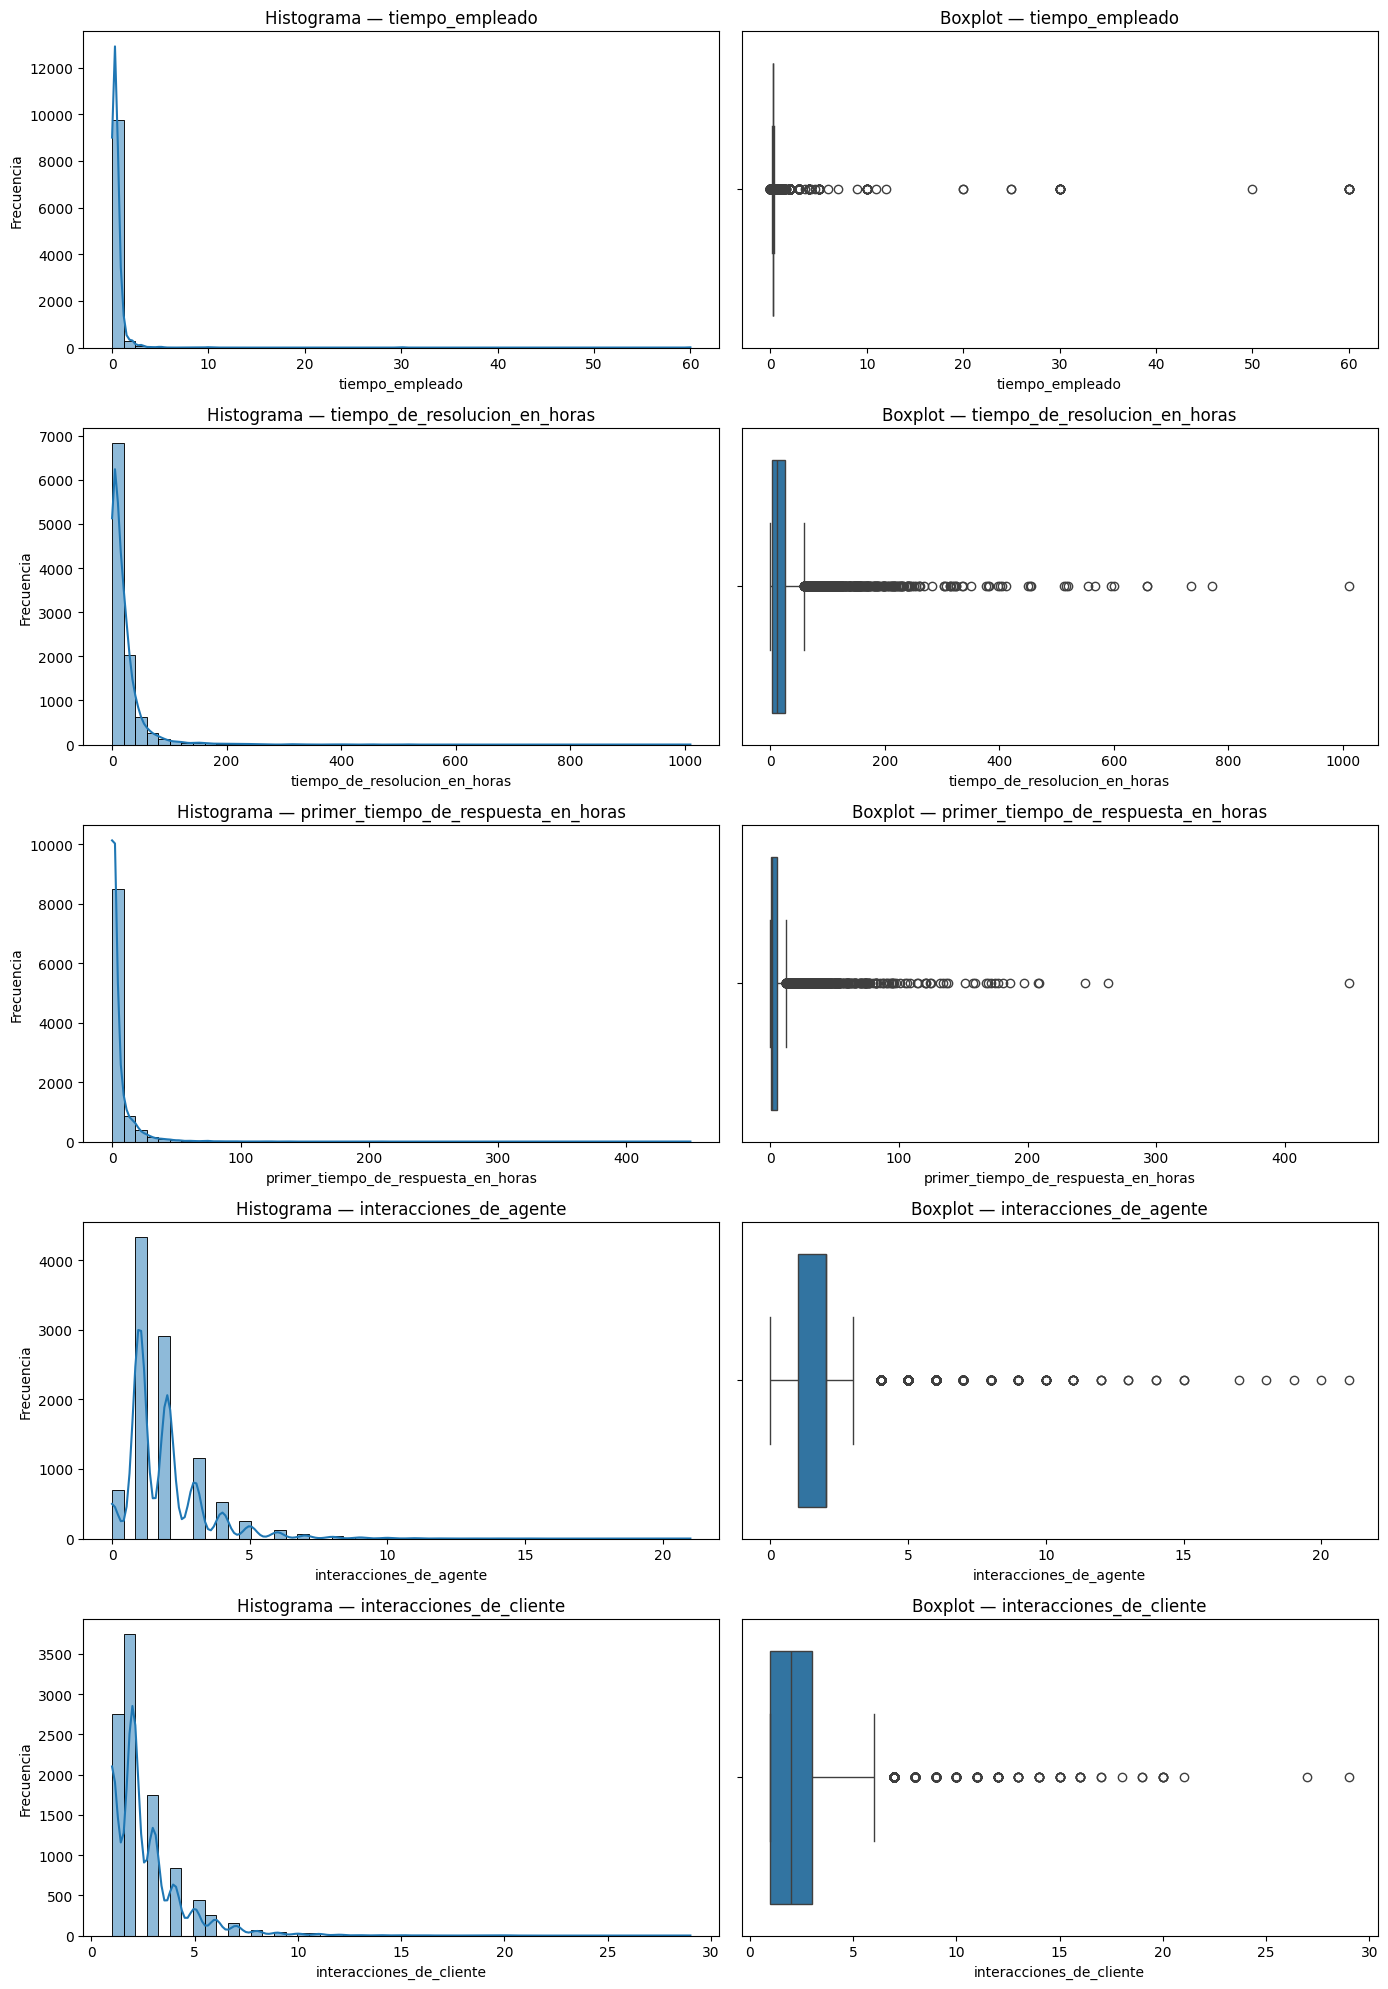

In [108]:
# Visualización univariada
fig, axes = plt.subplots(len(vars_numericas), 2, figsize=(14, 4 * len(vars_numericas)))

for i, col in enumerate(vars_numericas):
    serie = df_no_proyectos[col].astype(float).dropna()
    sns.histplot(serie, ax=axes[i, 0], kde=True, bins=50)
    axes[i, 0].set_title(f'Histograma — {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frecuencia')

    sns.boxplot(x=serie, ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot — {col}')
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()

### 2. Detección Bivariada — Cruce con prioridad y SLA

Analizamos `tiempo_de_resolucion_en_horas` vs. `prioridad`:

- **Boxplot por prioridad** con línea horizontal del SLA  (contexto visual de cuántos tickets exceden el SLA dentro de cada categoría).
- **Umbral de outlier bivariado = P99 por prioridad**  (el 1% más extremo *dentro de cada grupo de prioridad* queda marcado).
- **Scatterplot** `tiempo_empleado` vs. `tiempo_de_resolucion_en_horas` (coloreado por prioridad, para detectar combinaciones anómalas).

**¿Por qué P99 por prioridad y no IQR global ni SLA simple?**
- IQR sobre la distribución global marcaría demasiados casos (la distribución es log-normal, sesgo a la derecha).
- El SLA solo no funciona: 31% del dataset ya tiene `estado_de_resolucion = "SLA Violated"` es incumplimiento normal, no anomalía.
- **P99 por prioridad** sale del propio dato y se adapta naturalmente a cada categoría operativa.

**SLA por prioridad (regla de negocio):**
| Prioridad | SLA |
|---|---|
| Urgent | 4 h |
| High | 8 h |
| Medium | 24 h |
| Low | 72 h |

In [109]:
sla_horas = {'Urgent': 4, 'High': 8, 'Medium': 24, 'Low': 72}

# Umbral P99 de tiempo_de_resolucion_en_horas por prioridad
p99_por_prioridad = df_no_proyectos.groupby('prioridad', observed=True)['tiempo_de_resolucion_en_horas'].quantile(0.99)

print("Umbral P99 de tiempo_de_resolucion_en_horas por prioridad:")
print(f"{'Prioridad':<10} {'SLA(h)':>8} {'P99(h)':>10} {'P99/SLA':>10}")
for prio, p99 in p99_por_prioridad.items():
    sla = sla_horas.get(prio, np.nan)
    ratio = p99 / sla if sla else np.nan
    print(f"{prio:<10} {sla:>8} {p99:>10.1f} {ratio:>10.1f}×")

umbral_por_fila = df['prioridad'].astype(str).map(p99_por_prioridad).astype(float)

df['es_outlier_bivar'] = (
    (df['tiempo_de_resolucion_en_horas'] > umbral_por_fila) &
    (~df['es_proyecto_largo'])
)

print(f"\nOutliers bivariados detectados: {df['es_outlier_bivar'].sum()} "f"({df['es_outlier_bivar'].mean()*100:.2f}%)")
print("\nDesglose por prioridad:")
print(df[df['es_outlier_bivar']].groupby('prioridad', observed=True).size())


Umbral P99 de tiempo_de_resolucion_en_horas por prioridad:
Prioridad    SLA(h)     P99(h)    P99/SLA
High              8      246.9       30.9×
Low              72      147.2        2.0×
Medium           24      102.3        4.3×
Urgent            4      326.7       81.7×

Outliers bivariados detectados: 103 (1.01%)

Desglose por prioridad:
prioridad
High       5
Low       82
Medium     8
Urgent     8
dtype: int64


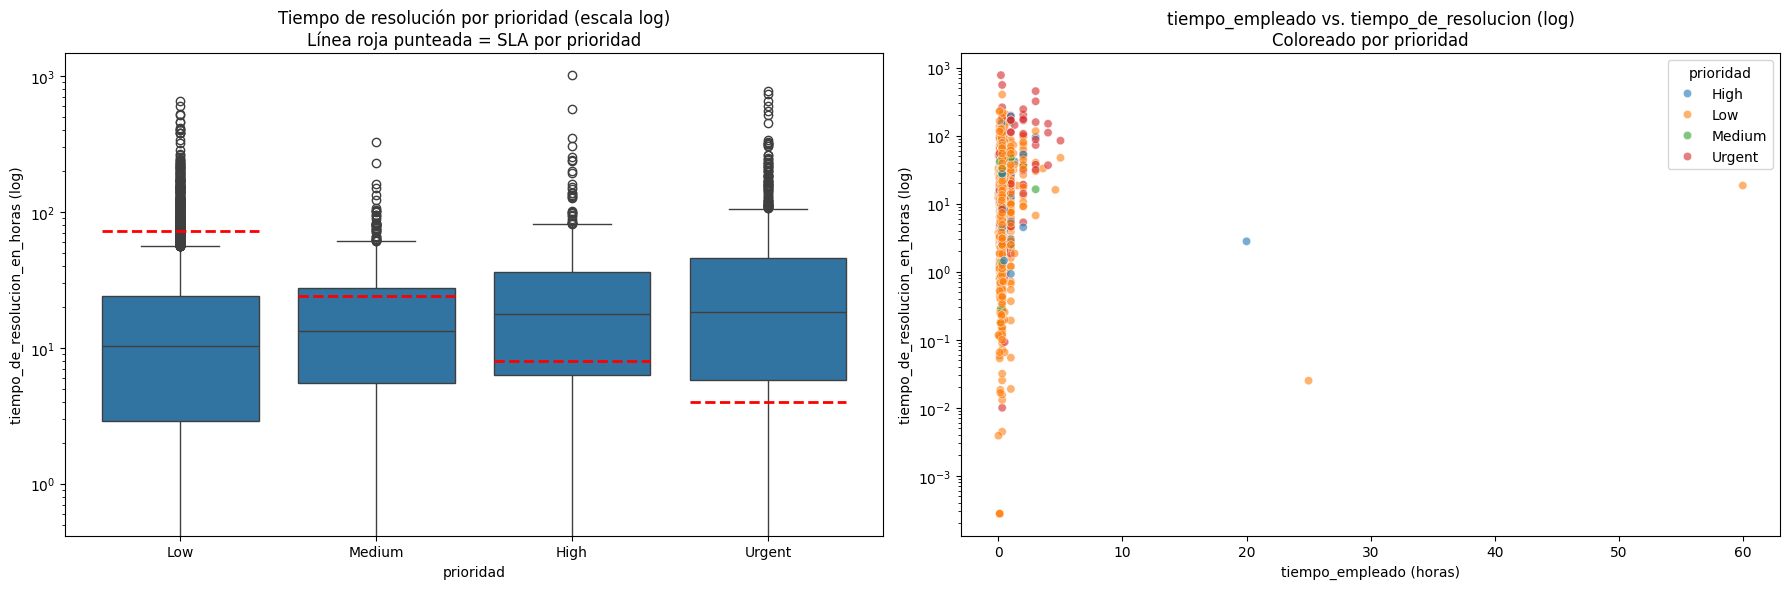

In [110]:
# Visualizaciones bivariadas
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Boxplot tiempo_de_resolucion por prioridad con líneas de SLA
orden_prio = [p for p in ['Low', 'Medium', 'High', 'Urgent'] if p in df_no_proyectos['prioridad'].unique()]
sns.boxplot(
    data=df_no_proyectos,
    x='prioridad', y='tiempo_de_resolucion_en_horas',
    order=orden_prio, ax=axes[0]
)
axes[0].set_yscale('log')
axes[0].set_title('Tiempo de resolución por prioridad (escala log)\nLínea roja punteada = SLA por prioridad')
axes[0].set_ylabel('tiempo_de_resolucion_en_horas (log)')

# Líneas horizontales de SLA por prioridad (segmentos)
for i, prio in enumerate(orden_prio):
    axes[0].hlines(sla_horas[prio], i - 0.4, i + 0.4, colors='red', linestyles='--', linewidth=2)

# Scatterplot (muestra de 2000 filas para legibilidad)
muestra = df_no_proyectos.sample(min(2000, len(df_no_proyectos)), random_state=42)
sns.scatterplot(
    data=muestra,
    x='tiempo_empleado', y='tiempo_de_resolucion_en_horas',
    hue='prioridad', alpha=0.6, ax=axes[1]
)
axes[1].set_yscale('log')
axes[1].set_title('tiempo_empleado vs. tiempo_de_resolucion (log)\nColoreado por prioridad')
axes[1].set_xlabel('tiempo_empleado (horas)')
axes[1].set_ylabel('tiempo_de_resolucion_en_horas (log)')

plt.tight_layout()
plt.show()

  - La mediana de tiempo de resolución crece con la prioridad (Low ~10h, Medium ~14h, High ~18h, Urgent ~20h). Esto es contradictorio porque los Urgent deberían resolverse más rápido. Por lo cual representa un imcumplimiento por el lado de la empresa.
  - Cruzado con la línea roja de SLA:                                                                                                                                     
    - Low (72h) y Medium (24h): la mediana está bien por debajo del SLA. Se cumple.                                                                                                                  
    - High (8h) y Urgent (4h): la mediana supera el SLA por 2.5× a 5×. No se cumple.                                                                                                                 
  - Insight de negocio: el sistema de soporte de Promotick prioriza el SLA en categorías bajas, pero falla sistemáticamente en alta prioridad.                                                       
  - El scatter muestra que el tiempo_empleado (trabajo activo) casi siempre es <5h sin importar cuánto dure el ticket

### 3. Detección Multivariada — Distancia de Mahalanobis

Aplicamos la distancia de Mahalanobis sobre el vector:
`[tiempo_empleado, tiempo_de_resolucion_en_horas, primer_tiempo_de_respuesta_en_horas, interacciones_de_agente, interacciones_de_cliente]`

Con esta distancia detectamos combinaciones de variables anómalas que individualmente podrían pasar desapercibidas (por ejemplo: un ticket con tiempo de resolución corto pero con muchísimas interacciones).

Umbral Mahalanobis² (chi² df=5, 99.7%): 17.96
Outliers multivariados detectados: 351 (3.45%)


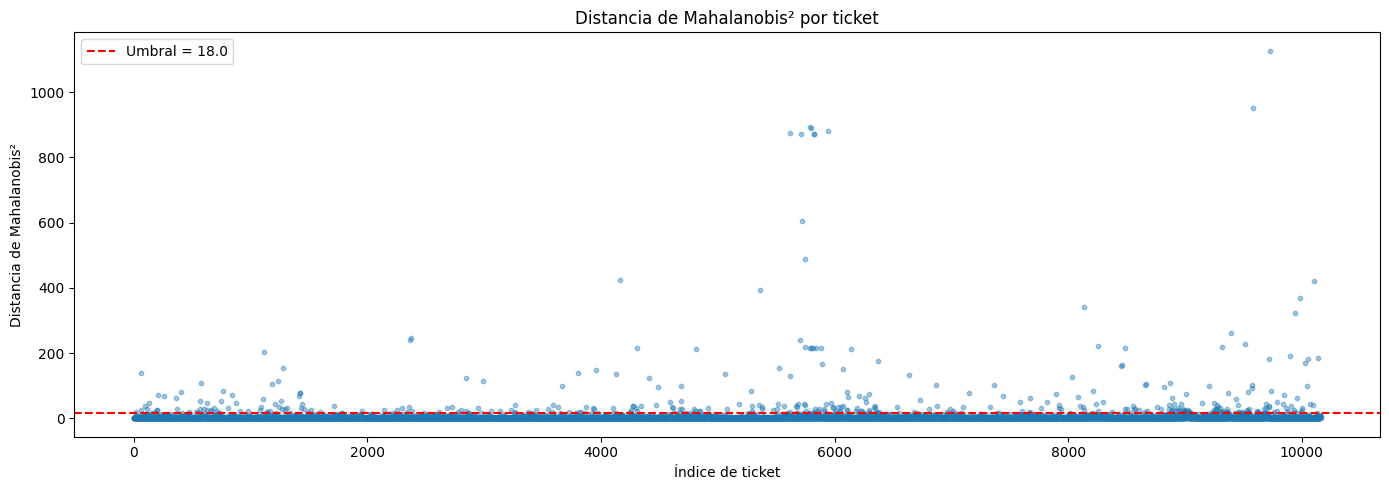

In [111]:
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2

# Estandarización min-max sobre el dataset sin proyectos
Xs = df_no_proyectos[vars_numericas].astype(float).copy()
Xs = (Xs - Xs.min()) / (Xs.max() - Xs.min())

# Matriz de covarianza inversa
Sx = Xs.cov().values
IC = np.linalg.pinv(Sx)
media = Xs.mean().values

# Distancia de Mahalanobis al cuadrado por fila
def mahalanobisR(X, media, IC):
    return [mahalanobis(X.iloc[i, :], media, IC) ** 2 for i in range(X.shape[0])]

dist_maha = pd.Series(mahalanobisR(Xs, media, IC), index=Xs.index)

# Umbral teórico: chi-cuadrado con k grados de libertad al 99.7%
k = len(vars_numericas)
umbral_maha = chi2.ppf(0.997, df=k)
print(f"Umbral Mahalanobis² (chi² df={k}, 99.7%): {umbral_maha:.2f}")

# Asignar distancia y flag al df principal
df['dist_mahalanobis'] = np.nan
df.loc[dist_maha.index, 'dist_mahalanobis'] = dist_maha.values
df['es_outlier_multivar'] = (df['dist_mahalanobis'] > umbral_maha).fillna(False)

print(f"Outliers multivariados detectados: {df['es_outlier_multivar'].sum()} "f"({df['es_outlier_multivar'].mean()*100:.2f}%)")

# Visualización: índice vs distancia
plt.figure(figsize=(14, 5))
plt.scatter(range(len(dist_maha)), dist_maha.values, alpha=0.4, s=10)
plt.axhline(umbral_maha, color='red', linestyle='--', label=f'Umbral = {umbral_maha:.1f}')
plt.xlabel('Índice de ticket')
plt.ylabel('Distancia de Mahalanobis²')
plt.title('Distancia de Mahalanobis² por ticket')
plt.legend()
plt.tight_layout()
plt.show()

### 4. Manejo de Outliers

Se construye la columna **`tipo_outlier`** que clasifica cada ticket en una de cinco categorías:

| Categoría | Significado |
|---|---|
| `normal` | Sin marcas de outlier |
| `proyecto_legitimo` | Ticket de cambio/proyecto — duración larga esperada por negocio |
| `outlier_bivar` | Supera el P99 del `tiempo_de_resolucion_en_horas` de su prioridad |
| `outlier_multivar` | Distancia de Mahalanobis sobre el umbral (combinación atípica de variables) |
| `outlier_ambos` | Marcado tanto bivariado como multivariado — caso más sospechoso |

Y se generan **dos datasets** para análisis posterior:
- `df_completo` — todas las filas con flags (preserva la trazabilidad).
- `df_filtrado` — solo `normal` + `proyecto_legitimo` (para análisis sin sesgo por outliers).

In [112]:
# Consolidación de las flags en una sola columna `tipo_outlier`
def clasificar_outlier(row):
    if row['es_proyecto_largo']:
        return 'proyecto_legitimo'
    if row['es_outlier_bivar'] and row['es_outlier_multivar']:
        return 'outlier_ambos'
    if row['es_outlier_bivar']:
        return 'outlier_bivar'
    if row['es_outlier_multivar']:
        return 'outlier_multivar'
    return 'normal'

df['tipo_outlier'] = df.apply(clasificar_outlier, axis=1).astype('category')

# Resumen de la clasificación
print("Distribución de la clasificación final de outliers:")
print(df['tipo_outlier'].value_counts())
print(f"\nTotal de filas: {len(df)}")
print(f"% no-normales: {(df['tipo_outlier'] != 'normal').mean()*100:.2f}%")

# Datasets comparativos para el análisis posterior
df_completo = df.copy()
df_filtrado = df[df['tipo_outlier'].isin(['normal', 'proyecto_legitimo'])].copy()

print(f"\ndf_completo: {df_completo.shape}")
print(f"df_filtrado (sin outliers estadísticos): {df_filtrado.shape}")
print(f"Filas excluidas en df_filtrado: {len(df_completo) - len(df_filtrado)} "
      f"({(len(df_completo) - len(df_filtrado))/len(df_completo)*100:.2f}%)")

Distribución de la clasificación final de outliers:
tipo_outlier
normal              9802
outlier_multivar     257
outlier_ambos         94
outlier_bivar          9
Name: count, dtype: int64

Total de filas: 10162
% no-normales: 3.54%

df_completo: (10162, 37)
df_filtrado (sin outliers estadísticos): (9802, 37)
Filas excluidas en df_filtrado: 360 (3.54%)


Estadísticos descriptivos: df_completo vs df_filtrado

--- tiempo_de_resolucion_en_horas ---


,df_completo,df_filtrado,diff_%
count,10162.00,9802.00,-3.54
mean,21.62,17.21,-20.41
std,39.39,20.04,-49.11
min,0.00,0.00,NaN
25%,3.26,3.09,-5.10
50%,11.61,10.83,-6.76
75%,25.55,23.99,-6.11
max,1010.04,157.45,-84.41



--- tiempo_empleado ---


,df_completo,df_filtrado,diff_%
count,10162.00,9802.00,-3.54
mean,0.51,0.40,-22.10
std,2.02,0.43,-78.59
min,0.00,0.00,NaN
25%,0.25,0.25,0.00
50%,0.30,0.30,0.00
75%,0.30,0.30,0.00
max,60.00,6.00,-90.00


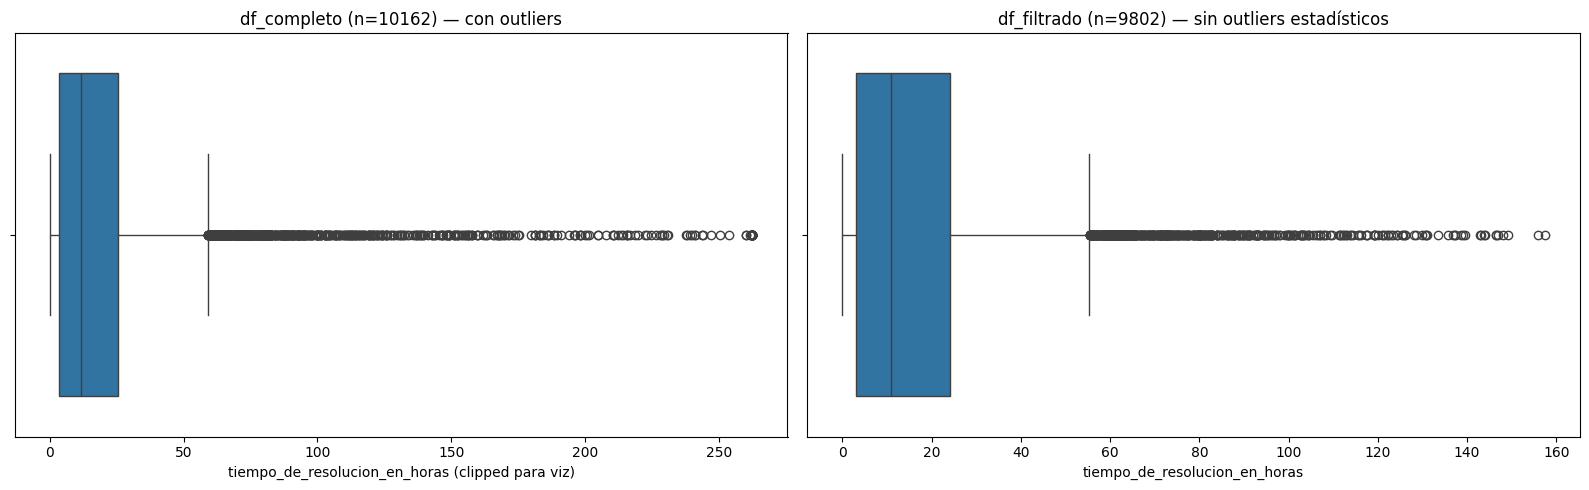

In [113]:
# Análisis comparativo: con vs. sin outliers estadísticos
print("Estadísticos descriptivos: df_completo vs df_filtrado")
print("\n--- tiempo_de_resolucion_en_horas ---")
comparacion = pd.DataFrame({
    'df_completo': df_completo['tiempo_de_resolucion_en_horas'].describe(),
    'df_filtrado': df_filtrado['tiempo_de_resolucion_en_horas'].describe(),
})
comparacion['diff_%'] = ((comparacion['df_filtrado'] - comparacion['df_completo']) / comparacion['df_completo'] * 100).round(2)
display(comparacion.round(2))

print("\n--- tiempo_empleado ---")
comparacion_te = pd.DataFrame({
    'df_completo': df_completo['tiempo_empleado'].describe(),
    'df_filtrado': df_filtrado['tiempo_empleado'].describe(),
})
comparacion_te['diff_%'] = ((comparacion_te['df_filtrado'] - comparacion_te['df_completo']) / comparacion_te['df_completo'] * 100).round(2)
display(comparacion_te.round(2))

# Visualización comparativa (boxplot lado a lado, estilo Ejercicio 8 del U3_L5)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cap_visual = df_completo['tiempo_de_resolucion_en_horas'].quantile(0.99) * 1.5

sns.boxplot(x=df_completo['tiempo_de_resolucion_en_horas'].clip(upper=cap_visual), ax=axes[0])
axes[0].set_title(f'df_completo (n={len(df_completo)}) — con outliers')
axes[0].set_xlabel('tiempo_de_resolucion_en_horas (clipped para viz)')

sns.boxplot(x=df_filtrado['tiempo_de_resolucion_en_horas'], ax=axes[1])
axes[1].set_title(f'df_filtrado (n={len(df_filtrado)}) — sin outliers estadísticos')
axes[1].set_xlabel('tiempo_de_resolucion_en_horas')

plt.tight_layout()
plt.show()

# Persistencia de los datasets
import os
os.makedirs('data', exist_ok=True)
df_completo.to_csv('data/tickets_promotick_completo.csv', index=False)
df_filtrado.to_csv('data/tickets_promotick_filtrado.csv', index=False)

La forma de la distribución es prácticamente idéntica con/sin outliers, no dominan la distribución central, pero sí extienden un poco la cola. Por lo cual tomamos la decisión de no eliminar del dataset principal.  

#### Resumen y justificación técnica

| Componente | Método aplicado | Justificación |
|---|---|---|
| Errores físicos | `tiempo_empleado < 0` = NaN | Las horas trabajadas no pueden ser negativas. |
| Proyectos legítimos | Filtro textual sobre `tipo` / `tipo_de_solicitud` | Regla de negocio confirmada con la empresa: los tickets de cambio pueden durar meses. |
| Univariado | IQR + histograma + boxplot + tabla de percentiles | Sirve como diagnóstico; no se aplica como filtro final por la naturaleza log-normal de los tiempos. |
| Bivariado | P99 por prioridad + SLA como referencia visual | El umbral sale del propio dato. Usar el SLA como umbral marcaría >30% del dataset como outlier — es incumplimiento, no anomalía. |
| Multivariado | Distancia de Mahalanobis + umbral chi² | Método del curso. Umbral ajustado a `chi²(df=5, 0.997) ≈ 18.2` por las 5 variables analizadas |
| Manejo | Flags consolidadas + dataset comparativo (`df_completo` y `df_filtrado`) | No se eliminan filas del dataset principal para preservar trazabilidad y permitir análisis con/sin outliers. |

### Integración, Reducción y Transformación de datos

La mayoría de las operaciones **ya se ejecutaron** dentro de los Niveles I, II y III de limpieza; aquí se consolidan y justifican.

---

##### A) Integración de datos

**Estado: No aplica al alcance del proyecto.**

El proyecto trabaja sobre un único origen de datos: el export del sistema de tickets de Promotick (`9000678639_tickets-April-24-2026-21_21.xls`). No existe una segunda fuente que integrar (CRM, base de clientes, sistema de facturación, etc.) dentro del alcance acordado con la empresa.

---

##### B) Reducción de datos

**Estado: Aplicada en tres pasos durante los Niveles I y III.**

| Paso | Acción | Detalle | Resultado |
|---|---|---|---|
| 1 | Drop de columnas 100% nulas | `dropna(how='all', axis=1)` en Fase 1 | 45 → 37 columnas (−8 cols) |
| 2 | Drop de columnas descontinuadas | `tiempo_de_seguimiento`, `estado_de_la_aprobacion`, `jefe_de_ti_que_aprueba_la_solicitud`, `producto`, `id_de_contacto` | 37 → 32 columnas (−5 cols) |
| 3 | Casteo a `category` | 18 variables categóricas pasaron de `str` a `category` | Memoria: 2.9 MB → 1.4 MB (−52%) |

**Justificación de cada decisión:**
- **Columnas 100% nulas** (`Contacto`, `Teléfono`, `Ubicación del servicio`, `Hora de inicio/finalización de la cita`, `Firma del cliente`, `Estados de todas las respuestas`, `Información de la fuente`): no aportan información — son artefactos del export.
- **Columnas descontinuadas**: confirmadas con el representante de Promotick como no utilizadas en los procesos analíticos actuales (administrativas o redundantes).
- **`category` en lugar de `object`**: las 18 variables tienen pocos niveles repetidos.

**Reducción no realizada (decisión justificada):**
- Mantenemos `nombre_completo` (207 únicos) pese a ser PII. Se conserva para el análisis de carga por agente, con el compromiso de **no exportar este campo** en el dataset final entregable o reemplazarlo por un hash.

---

##### C) Transformación de datos

**Estado: Aplicada en los Niveles I, II y III.**

| Componente | Variables afectadas | Transformación | Dónde |
|---|---|---|---|
| Normalización de nombres | Todas | `snake_case`, sin acentos, sin caracteres especiales | Fase 1 |
| Estandarización de nulos | Todas | `"None"`, `"NaN"`, `""`, `"null"` → `np.nan` | Fase 1 |
| Trimming de strings | Todas las `object` | `.str.strip()` | Fase 1 |
| Parseo de fechas | 8 columnas | `to_datetime(errors='coerce')` → `datetime64[us]` | Fase 2 + Final |
| Parseo de duraciones | `primer_tiempo_de_respuesta_en_horas`, `tiempo_de_resolucion_en_horas` | `"0 days HH:MM:SS"` → `timedelta` → horas `float64` | Fase 2 |
| Casteo numérico | `interacciones_de_agente`, `interacciones_de_cliente` | `Int64` (entero con soporte de NaN) | Fase 2 |
| Casteo numérico continuo | `tiempo_empleado` | `float64` | Fase 2 |
| Imputación condicional | `tiempo_empleado` | Mediana **por prioridad** (en lugar de media global) | Nivel III |
| Reparación cronológica | `hora_de_cierre`, `inicio_de_atencion`, `fin_de_atencion` | Fillna con la fecha lógica más cercana | Nivel III |
| Casteo categórico | 18 variables | `object` → `category` | Casteo Estricto |
| Corrección de error físico | `tiempo_empleado < 0` | NaN + reimputación por mediana de prioridad | Sección Outliers |

Hacemos una validación: detección de inconsistencias residuales en variables categóricas, es decir buscamos "falsos niveles", variables de la misma categoría que difieren en mayúsculas/acentos/espacios y se normalizan.

In [114]:
import unicodedata

def normalizar_clave(valor):
    if pd.isna(valor):
        return valor
    s = str(valor).strip().lower()
    s = ''.join(c for c in unicodedata.normalize('NFD', s)
                if unicodedata.category(c) != 'Mn')
    return s

cols_categoricas = df.select_dtypes(include='category').columns.tolist()
print(f"Variables categóricas a auditar: {len(cols_categoricas)}\n")

inconsistencias_detectadas = {}
for col in cols_categoricas:
    valores = df[col].dropna().unique()
    grupos = {}
    for v in valores:
        clave = normalizar_clave(v)
        grupos.setdefault(clave, []).append(v)
    duplicados = {k: vs for k, vs in grupos.items() if len(vs) > 1}
    if duplicados:
        inconsistencias_detectadas[col] = duplicados

if inconsistencias_detectadas:
    print("Inconsistencias residuales detectadas (mismo concepto, diferente escritura):")
    for col, dup in inconsistencias_detectadas.items():
        print(f"\n  {col}:")
        for clave, variantes in dup.items():
            print(f"    '{clave}' aparece como: {variantes}")
else:
    print("Sin inconsistencias residuales — todas las variables categóricas están normalizadas.")
    print("\nResumen de cardinalidad por variable categórica:")
    cardinalidad = pd.Series(
        {col: df[col].nunique() for col in cols_categoricas}
    ).sort_values(ascending=False)
    display(cardinalidad.to_frame('niveles_unicos'))

Variables categóricas a auditar: 19

Inconsistencias residuales detectadas (mismo concepto, diferente escritura):

  asunto:
    'desactivar banner de beneficios tebca' aparece como: ['desactivar banner de beneficios tebca', 'desactivar banner de Beneficios Tebca']
    'extension de vigencia' aparece como: ['EXTENSIÓN DE VIGENCIA', 'EXTENSION DE VIGENCIA']
    'carga banner +ventas legrand' aparece como: ['Carga banner +Ventas Legrand', 'Carga Banner +ventas Legrand']
    'actualizacion catalogo +ventas legrand' aparece como: ['Actualización catalogo +ventas Legrand', 'Actualización catalogo +Ventas Legrand']
    'locales tebca' aparece como: ['Locales Tebca', 'Locales tebca']
    'banners beneficios vsp' aparece como: ['Banners Beneficios VSP', 'banners beneficios VSP']
    'inactivar' aparece como: ['Inactivar', 'inactivar']
    'desbloquear cuenta giftealo' aparece como: ['desbloquear cuenta Giftealo', 'Desbloquear cuenta Giftealo', 'Desbloquear cuenta giftealo']
    'desactivar pla

#### Canonicalización de inconsistencias residuales detectadas

La auditoría anterior encontró variantes textuales del mismo concepto en `asunto`, `nombre_completo` y otras categóricas (mayúsculas/acentos/espacios). Por lo cual decidimos los siguiente:

- **Estrategia**: para cada grupo de variantes con la misma clave normalizada (minúsculas + sin acentos + sin espacios extra), se elige como **canónica la variante más frecuente** y se reemplazan las demás. Es determinista, preserva el formato más usado y aplica uniformemente.
- **`asunto`**: además de canonicalizar, se convierte de `category` a `object` — con miles de únicos no aprovecha el dtype `category` y es texto libre humano, no una taxonomía cerrada.
- **`nombre_completo`** y demás categóricas: se canonicaliza y se mantiene `category` (para asegurar que cada agente aparezca como una sola entidad)

In [115]:
def canonicalizar(serie):
    serie_str = serie.astype(str)
    claves = serie_str.map(normalizar_clave)
    aux = pd.DataFrame({'original': serie_str.values, 'clave': claves.values}, index=serie.index)
    # Variante canónica por clave normalizada = la moda dentro de cada grupo
    canonico_por_clave = (
        aux.groupby('clave')['original']
        .agg(lambda s: s.value_counts().idxmax())
    )
    return claves.map(canonico_por_clave)

cols_a_canonicalizar = list(inconsistencias_detectadas.keys())
print(f"Columnas a canonicalizar: {cols_a_canonicalizar}\n")

resumen = []
for col in cols_a_canonicalizar:
    n_antes = df[col].nunique()
    serie_canonica = canonicalizar(df[col])
    if col == 'asunto':
        # asunto es texto libre con miles de únicos: lo dejamos como object
        df[col] = serie_canonica.astype('object')
    else:
        df[col] = serie_canonica.astype('category')
    n_despues = df[col].nunique()
    resumen.append({'columna': col, 'unicos_antes': n_antes, 'unicos_despues': n_despues, 'reduccion': n_antes - n_despues})

print("Resumen de canonicalización:")
display(pd.DataFrame(resumen))


Columnas a canonicalizar: ['asunto', 'etiquetas', 'nombre_completo']

Resumen de canonicalización:


,columna,unicos_antes,unicos_despues,reduccion
0,asunto,7342,7232,110
1,etiquetas,252,246,6
2,nombre_completo,207,206,1


In [116]:
# Re-validación: confirmamos que ya no hay inconsistencias residuales
inconsistencias_post = {}
cols_post = df.select_dtypes(include=['category', 'object']).columns.tolist()
# Excluimos id y campos que no son verdaderas categóricas
cols_post = [c for c in cols_post if c not in ('id_del_ticket',)]

for col in cols_post:
    valores = df[col].dropna().unique()
    grupos = {}
    for v in valores:
        clave = normalizar_clave(v)
        grupos.setdefault(clave, []).append(v)
    dup = {k: vs for k, vs in grupos.items() if len(vs) > 1}
    if dup:
        inconsistencias_post[col] = dup

if inconsistencias_post:
    print("Aún quedan inconsistencias:")
    for col, dup in inconsistencias_post.items():
        print(f"  {col}: {len(dup)} grupos")
else:
    print("Sin inconsistencias residuales — todas las variables están normalizadas.")
print(f"\nDimensiones finales del dataset: {df.shape}")


Sin inconsistencias residuales — todas las variables están normalizadas.

Dimensiones finales del dataset: (10162, 37)


#### Feature Engineering: variables derivadas y atributos construidos

Las métricas que nos piden para ambos dashboard requiren de variables derivadas como atributos construidos.

# Indicadores del Sistema de Tickets

## 1. Operacionales

- **Tickets Abiertos:** Cantidad de tickets pendientes de atención.
- **Tickets Cerrados:** Cantidad de tickets resueltos en un período.
- **Backlog de Tickets:** Diferencia entre tickets abiertos y cerrados.
- **Tiempo Promedio de Atención:** Tiempo promedio desde el registro hasta el cierre del ticket.
- **Tiempo de Primera Respuesta:** Tiempo transcurrido hasta el primer contacto con el usuario.
- **Cumplimiento de SLA:** Porcentaje de tickets resueltos dentro del SLA.
- **Tickets por Prioridad:** Distribución de tickets según prioridad (Alta, Media, Baja).
- **Tickets por Categoría:** Distribución de tickets por tipo de servicio.
- **Tickets Reabiertos:** Cantidad de tickets reabiertos luego del cierre.
- **Tickets por Analista:** Cantidad de tickets atendidos por cada analista.

## 2. Gerenciales

- **Tendencia de Tickets:** Evolución del volumen de tickets por período.
- **Backlog Crítico:** Tickets de alta prioridad pendientes.
- **Incidentes Recurrentes:** Problemas que se repiten y requieren análisis de causa raíz.
- **Categorías con Mayor Incidencia.**
- **Nivel de Saturación Operativa:** Relación entre demanda y capacidad del equipo de soporte.
- **Demanda por Área:** Áreas de negocio con mayor volumen de solicitudes.
- **Comparativo Mensual de Atención:** Variación del desempeño respecto a períodos anteriores.
- **Indicadores de Mejora Continua:** Métricas orientadas a prevención y optimización del servicio.


###
Comenzemos con las variables y atributos para el dashboard Operacional

- **Tickets Abiertos:** Cantidad de tickets pendientes de atención.
- **Tickets Cerrados:** Cantidad de tickets resueltos en un período.
- **Backlog de Tickets:** Diferencia entre tickets abiertos y cerrados.

In [117]:
estados_posibles = ['Resolved', 'Closed', 'Open']
df['estado'] = pd.Categorical(df['estado'], categories=estados_posibles)
df_estado = pd.get_dummies(df['estado'], dtype=int)
df_estado.columns = df_estado.columns.astype(str)
df_final = df.join(df_estado).drop(columns=['estado'])
df_final.rename(columns={'Closed': 'estado_closed', 'Open': 'estado_open', 'Resolved': 'estado_resolved'}, inplace=True)

In [118]:
df_final.head(1)

,id_del_ticket,asunto,prioridad,fuente,tipo,agente,grupo,tiempo_de_creacion,vencidas_hasta_ahora,tiempo_de_resolucion,...,dependencias,nombre_completo,es_proyecto_largo,es_outlier_bivar,dist_mahalanobis,es_outlier_multivar,tipo_outlier,estado_resolved,estado_closed,estado_open
0,48543,URGENTE- MAS VENTAS MAS PREMIOS,Low,Portal,Solicitud Operativa,No Agent,No Group,2024-01-02 08:55:58,2024-01-03 18:00:00,2024-01-02 09:15:36,...,Ninguna,Alexia Trujillo,False,False,0.860402,False,normal,0,1,0


In [119]:
tickets_abiertos = df_final['estado_open'].sum()
tickets_resueltos = df_final['estado_resolved'].sum()
tickets_cerrados = df_final['estado_closed'].sum()

print("tickets_abiertos: ",tickets_abiertos)
print("tickets_resueltos: ",tickets_resueltos)
print("tickets_cerrados: ",tickets_cerrados)
print("Backlog: ",tickets_abiertos-tickets_cerrados)

tickets_abiertos:  0
tickets_resueltos:  7
tickets_cerrados:  10155
Backlog:  -10155


- **Tiempo Promedio de Atención:** Tiempo promedio desde el registro hasta el cierre del ticket.
- **Tiempo de Primera Respuesta:** Tiempo transcurrido hasta el primer contacto con el usuario.

In [120]:
tiempo_primera_respuesta = df_final['primer_tiempo_de_respuesta_en_horas'].mean()
tiempo_primera_respuesta

np.float64(5.527764492991318)

In [121]:
tiempo_atencion = df_final['tiempo_de_resolucion_en_horas'].mean()
tiempo_atencion

np.float64(21.618233096065953)

- **Cumplimiento de SLA:** Porcentaje de tickets resueltos dentro del SLA.
- **Tickets por Prioridad:** Distribución de tickets según prioridad (Alta, Media, Baja).

In [122]:
df_sla = pd.get_dummies(df['estado_de_resolucion'], dtype=int)
df_sla.columns = df_sla.columns.astype(str)
df_final=df_final.join(df_sla).drop(columns=["estado_de_resolucion"])
df_final.rename(columns={"Within SLA": "within_SLA","SLA Violated":"sla_violated"}, inplace=True)

In [123]:
porcentaje_sla=df_final["within_SLA"].mean()*100
porcentaje_sla

np.float64(68.9529620153513)

In [124]:
df_prioridad = pd.get_dummies(df['prioridad'], dtype=int)
df_prioridad.columns = df_prioridad.columns.astype(str)
df_final=df_final.join(df_prioridad).drop(columns=["prioridad"])

In [125]:
prioridad_baja=df_final["Low"].sum()
prioridad_media=df_final["Medium"].sum()
prioridad_alta=df_final["Urgent"].sum()
print("Tickets con prioridad baja: ", prioridad_baja)
print("Tickets con prioridad media: ",prioridad_media)
print("Tickets con prioridad alta: ",prioridad_alta)

Tickets con prioridad baja:  8177
Tickets con prioridad media:  761
Tickets con prioridad alta:  783


- **Tickets por Categoría:** Distribución de tickets por tipo de servicio.
- **Tickets Reabiertos:** Cantidad de tickets reabiertos luego del cierre.
- **Tickets por Analista:** Cantidad de tickets atendidos por cada analista.

In [126]:
df['tipo'].value_counts()

tipo
Solicitud Operativa                     4397
Requerimiento de Servicio               3590
Incidente del Servicio                  1291
Soporte Tecnico                          487
Plantilla ENJOY                          225
No especificado                           68
Netsuite                                  44
Consultas                                 38
Incidentes                                17
Solicitud de Reunion                       2
Solicitud nuevo desarrollo - Cotizar       2
Capacitación                               1
Name: count, dtype: int64

In [127]:
df["agente"].value_counts()

agente
No Agent                             8309
Arturo Carbajal                       780
Sebastián Fabrizio Alvino Linares     522
Walter Umeres(Deactivated)            366
Jimena R                              118
Christian Carbajal                     25
Rodolfo Guerra                         19
Oscar Vargas                           13
Anilu Silva(Deactivated)               10
Name: count, dtype: int64

Ahora pasamos al dashboard gerencial.

- **Tendencia de Tickets:** Evolución del volumen de tickets por período.
- **Comparativo Mensual de Atención:** Variación del desempeño respecto a períodos anteriores.

In [128]:
df_final['tiempo_creacion_anio_mes'] = df_final['tiempo_de_creacion'].dt.to_period('M')
df_final['tiempo_creacion_anio_semana'] = df_final['tiempo_de_creacion'].dt.to_period('W')
df_final['tiempo_creacion_fecha_dia'] = df_final['tiempo_de_creacion'].dt.date

In [129]:
tendencia = df_final.groupby('tiempo_creacion_anio_mes').size()
tendencia

tiempo_creacion_anio_mes
2024-01    514
2024-02    512
2024-03    344
2024-04    489
2024-05    426
2024-06    387
2024-07    484
2024-08    362
2024-09    407
2024-10    484
2024-11    454
2024-12    420
2025-01    434
2025-02    436
2025-03    366
2025-04    491
2025-05    497
2025-06    388
2025-07    345
2025-08    369
2025-09    382
2025-10    460
2025-11    381
2025-12    330
Freq: M, dtype: int64

In [130]:
resumen_mensual = df_final.groupby('tiempo_creacion_anio_mes').agg(
    tickets=('id_del_ticket', 'count'),
    tiempo_prom_resolucion=('tiempo_de_resolucion_en_horas', 'mean'),
    pct_sla=('Within SLA', 'mean')
)
resumen_mensual['variacion_tickets_%'] = resumen_mensual['tickets'].pct_change() * 100

KeyError: "Column(s) ['Within SLA'] do not exist"

In [ ]:
resumen_mensual.head(12)

,tickets,tiempo_prom_resolucion,pct_sla,variacion_tickets_%
tiempo_creacion_anio_mes,,,,
2024-01,514,20.642955,0.607004,NaN
2024-02,512,21.297776,0.560547,-0.389105
2024-03,344,24.804052,0.610465,-32.812500
2024-04,489,17.563451,0.666667,42.151163
2024-05,426,16.254835,0.669014,-12.883436
2024-06,387,16.437870,0.653747,-9.154930
2024-07,484,15.194634,0.671488,25.064599
2024-08,362,15.468678,0.654696,-25.206612
2024-09,407,15.291130,0.722359,12.430939


- **Backlog Crítico:** Tickets de alta prioridad pendientes.

In [ ]:
df_final['critico'] = ((df_final['Urgent'] == 1) & (df_final['Open'] == 1)).astype(int)
backlog_critico = df_final['critico'].sum()
backlog_critico

np.int64(0)

- **Demanda por Área:** Áreas de negocio con mayor volumen de solicitudes.
- **Categorías con Mayor Incidencia.**

In [ ]:
df_final['grupo'].value_counts()

grupo
No Group                       5286
Centro de Servicios TI         4515
Seguridad de la Informacion     256
Sistemas de Informacion          47
Soporte Técnico                  39
Sistemas Financieros             19
Name: count, dtype: int64

In [ ]:
df_final['tipo'].value_counts().head(5)

tipo
Solicitud Operativa          4397
Requerimiento de Servicio    3590
Incidente del Servicio       1291
Soporte Tecnico               487
Plantilla ENJOY               225
Name: count, dtype: int64

- **Nivel de Saturación Operativa:** Relación entre demanda y capacidad del equipo de soporte.

In [ ]:
df_final.groupby('tiempo_creacion_anio_mes')['agente'].unique()

tiempo_creacion_anio_mes
2024-01    ['No Agent']
Categories (9, object): ['Anilu S...
2024-02    ['No Agent']
Categories (9, object): ['Anilu S...
2024-03    ['No Agent']
Categories (9, object): ['Anilu S...
2024-04    ['No Agent']
Categories (9, object): ['Anilu S...
2024-05    ['No Agent']
Categories (9, object): ['Anilu S...
2024-06    ['No Agent']
Categories (9, object): ['Anilu S...
2024-07    ['No Agent']
Categories (9, object): ['Anilu S...
2024-08    ['No Agent']
Categories (9, object): ['Anilu S...
2024-09    ['No Agent']
Categories (9, object): ['Anilu S...
2024-10    ['No Agent']
Categories (9, object): ['Anilu S...
2024-11    ['No Agent']
Categories (9, object): ['Anilu S...
2024-12    ['No Agent', 'Christian Carbajal']
Categories ...
2025-01    ['No Agent', 'Christian Carbajal', 'Arturo Car...
2025-02    ['No Agent', 'Arturo Carbajal', 'Christian Car...
2025-03    ['Arturo Carbajal', 'No Agent', 'Anilu Silva(D...
2025-04    ['No Agent', 'Walter Umeres(Deactivated)', 'Os...

In [ ]:
demanda = df_final.groupby('tiempo_creacion_anio_mes').size()
analistas_activos = df_final.groupby('tiempo_creacion_anio_mes')['agente'].nunique()
saturacion = (demanda / analistas_activos).rename('tickets_por_analista')
saturacion.tail(12)

tiempo_creacion_anio_mes
2025-01    86.800000
2025-02    72.666667
2025-03    52.285714
2025-04    70.142857
2025-05    99.400000
2025-06    77.600000
2025-07    86.250000
2025-08    73.800000
2025-09    76.400000
2025-10    92.000000
2025-11    63.500000
2025-12    55.000000
Freq: M, Name: tickets_por_analista, dtype: float64

- **Incidentes Recurrentes:** Problemas que se repiten y requieren análisis de causa raíz.

In [ ]:
recurrentes = df_final['origen_categoria'].value_counts()
recurrentes.describe()

count      49.000000
mean      207.387755
std       788.960889
min         1.000000
25%         4.000000
50%        24.000000
75%        99.000000
max      5293.000000
Name: count, dtype: float64

In [ ]:
recurrentes = recurrentes[recurrentes > 207]
recurrentes.head(10)

origen_categoria
No aplica                   5293
Actualización               1766
Error en el servicio Web     571
Carga                        492
Consultas                    297
Reportes                     280
Name: count, dtype: int64

Análisis y visualización de datos para búsqueda de insights